In [15]:
from hossam import load_data
from helpers import *
from pandas import DataFrame
import pandas as pd
from IPython.display import display, Markdown

import os               # 파일 및 디렉토리 경로를 처리하는 파이썬 내장 모듈
import joblib           # 학습된 모델을 파일로 저장하고 복원하는 직렬화 모듈
import numpy as np      # 수치계산을 위한 파이썬 내장 모듈
import glob as gl       # 파일 목록을 리스트로 반환하는 파이썬 내장 모듈
import datetime as dt   # 날짜 및 시간 처리를 위한 파이썬 내장 모듈

# 훈련, 검증 데이터 분리 함수
from sklearn.model_selection import train_test_split

# 성능평가 지표 계산 함수
from sklearn.metrics import (
    r2_score,                           # 결정계수 (R2)
    mean_absolute_error,                # 평균절대오차 (MAE)
    mean_squared_error,                 # 평균제곱오차 (MSE)
    mean_squared_log_error,             # 평균제곱로그오차 (MSLE)
    mean_absolute_percentage_error      # 평균절대백분율오차 (MAPE)
)

# 선형 계열 모델
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# 비선형 계열 모델
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# 트리계열 모델
from sklearn.tree import DecisionTreeRegressor

# 앙상블 모델
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [16]:
# 분석용 데이터 전처리가 완료된 데이터 셋
origin = pd.read_excel("streeteasy_features_log_labeled.xlsx")
df = my_qtcheck.set_type(origin, as_category=["bed_bath_constraint", "building_era", "cluster_name", "amenity_level"])

<class 'pandas.DataFrame'>
RangeIndex: 3512 entries, 0 to 3511
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   size_sqft            3512 non-null   float64 
 1   min_to_subway        3512 non-null   float64 
 2   building_era         3512 non-null   category
 3   relative_floor       3512 non-null   float64 
 4   relative_size        3512 non-null   float64 
 5   bed_bath_constraint  3512 non-null   category
 6   cluster_name         3512 non-null   category
 7   amenity_level        3512 non-null   category
 8   rent                 3512 non-null   float64 
dtypes: category(4), float64(5)
memory usage: 151.1 KB


## 4. 데이터에서 독립변수와 종속변수 분리
### 머신러닝에서는 독립변수를 feature, 종속변수를 target으로 명명한다.

In [17]:
feature = df.drop(columns=["rent"])
target = df["rent"]
feature.shape, target.shape

((3512, 8), (3512,))

## 5. 훈련, 검증 데이터 분리

In [18]:
# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2809, 8), (703, 8), (2809,), (703,))

## 6. 학습을 완료한 모델이 저장될 폴더

In [19]:
project_name = "streeteasy"
base_dir = f"{project_name}/baseline"

if not os.path.exists(base_dir):
    os.makedirs(base_dir)

작업 폴더: streeteasy\baseline
학습 완료 [ 1/11] : linear
학습 완료 [ 2/11] : ridge
학습 완료 [ 3/11] : lasso
학습 완료 [ 4/11] : elasticnet
학습 완료 [ 5/11] : kneighbors
학습 완료 [ 6/11] : svr
학습 완료 [ 7/11] : decisiontree
학습 완료 [ 8/11] : randomforest
학습 완료 [ 9/11] : xgb
학습 완료 [10/11] : lgbm
학습 완료 [11/11] : catboost


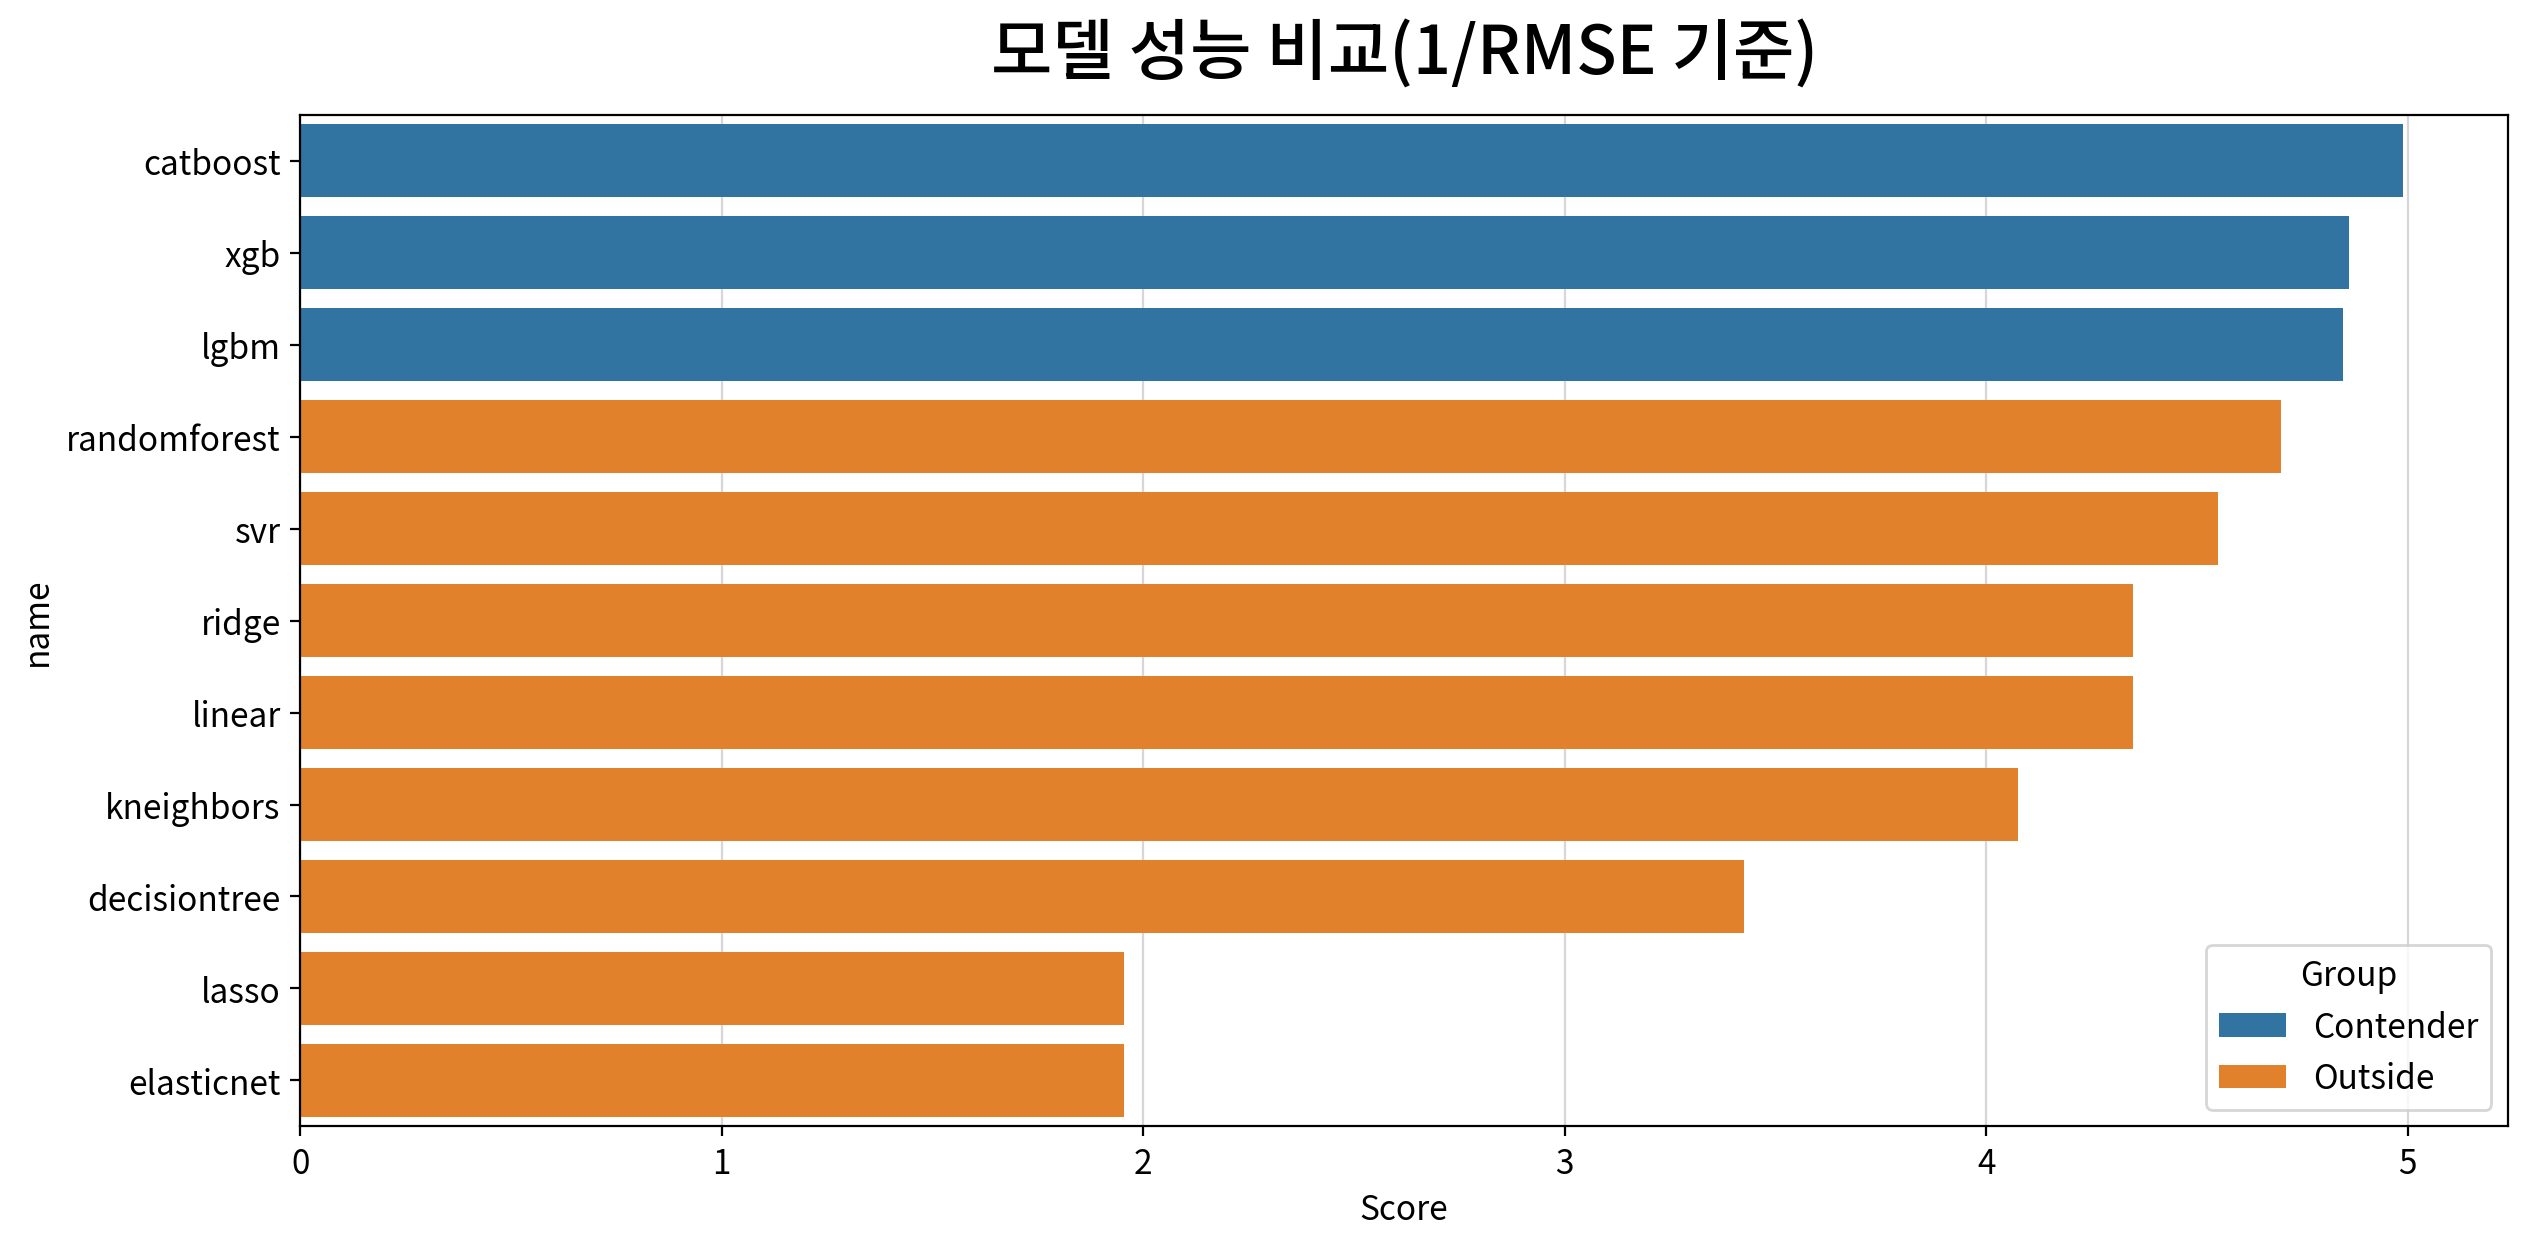


모델 11개 학습·저장 완료 → streeteasy\baseline


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
catboost,1,Contender,CatBoostRegressor,0.846,0.148,0.040,0.200,0.021,0.018,-0.001,0.000,4.988
xgb,2,Contender,XGBRegressor,0.838,0.153,0.042,0.206,0.022,0.018,-0.001,0.026,4.861
lgbm,3,Contender,LGBMRegressor,0.837,0.156,0.043,0.206,0.022,0.018,-0.001,0.029,4.846
randomforest,4,Outside,RandomForestRegressor,0.827,0.160,0.045,0.213,0.022,0.019,-0.001,0.062,4.699
svr,5,Outside,SVR,0.815,0.163,0.048,0.220,0.023,0.019,-0.001,0.096,4.549
ridge,6,Outside,Ridge,0.798,0.173,0.053,0.230,0.024,0.021,-0.001,0.147,4.349
linear,7,Outside,LinearRegression,0.798,0.173,0.053,0.230,0.024,0.021,-0.001,0.147,4.349
kneighbors,8,Outside,KNeighborsRegressor,0.770,0.185,0.060,0.245,0.026,0.022,0.001,0.224,4.076
decisiontree,9,Outside,DecisionTreeRegressor,0.674,0.218,0.085,0.292,0.031,0.026,-0.003,0.456,3.426


CPU times: total: 1min 39s
Wall time: 40.8 s


In [20]:
%%time
my_ml.reg_baseline("streeteasy", x_train, y_train, x_test, y_test)

## 튜닝 저장폴더 구성

In [21]:
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [22]:
# 튜닝하기 원하는 모델을 로드하여 딕셔너리 형태로 저장
models = {
    "linear": my_ml.load_model(f"{base_dir}/linear.pkl"),
    "ridge": my_ml.load_model(f"{base_dir}/ridge.pkl"),
    "lasso": my_ml.load_model(f"{base_dir}/lasso.pkl"),
    "elasticnet": my_ml.load_model(f"{base_dir}/elasticnet.pkl"),
    "kneighbors": my_ml.load_model(f"{base_dir}/kneighbors.pkl"),
    "svr": my_ml.load_model(f"{base_dir}/svr.pkl"),
    "decisiontree": my_ml.load_model(f"{base_dir}/decisiontree.pkl"),
    "randomforest": my_ml.load_model(f"{base_dir}/randomforest.pkl"),
    "xgb": my_ml.load_model(f"{base_dir}/xgb.pkl"),
    "lgbm": my_ml.load_model(f"{base_dir}/lgbm.pkl"),
    "catboost": my_ml.load_model(f"{base_dir}/catboost.pkl")
}

작업 폴더: streeteasy\tuned
탐색 범위: 실무용
탐색 완료 [ 1/11] : linear (0.3초, CV RMSE=0.2404)
    최적 조합: {'model__fit_intercept': True, 'model__positive': False}
탐색 완료 [ 2/11] : ridge (0.9초, CV RMSE=0.2404)
    최적 조합: {'model__alpha': 0.01, 'model__solver': 'auto'}
탐색 완료 [ 3/11] : lasso (0.7초, CV RMSE=0.2404)
    최적 조합: {'model__alpha': 0.0001, 'model__max_iter': 1000}
탐색 완료 [ 4/11] : elasticnet (0.8초, CV RMSE=0.2404)
    최적 조합: {'model__alpha': 0.0001, 'model__l1_ratio': 0.3}
탐색 완료 [ 5/11] : kneighbors (1.2초, CV RMSE=0.2373)
    최적 조합: {'model__n_neighbors': 20, 'model__p': 2, 'model__weights': 'distance'}
탐색 완료 [ 6/11] : svr (4.4초, CV RMSE=0.2236)
    최적 조합: {'model__C': 1.0, 'model__epsilon': 0.1, 'model__gamma': 0.1}
탐색 완료 [ 7/11] : decisiontree (1.0초, CV RMSE=0.2424)
    최적 조합: {'model__max_depth': 6, 'model__min_samples_leaf': 5}
탐색 완료 [ 8/11] : randomforest (18.0초, CV RMSE=0.2183)
    최적 조합: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 500}
탐색 완료 [ 9/11] : xg

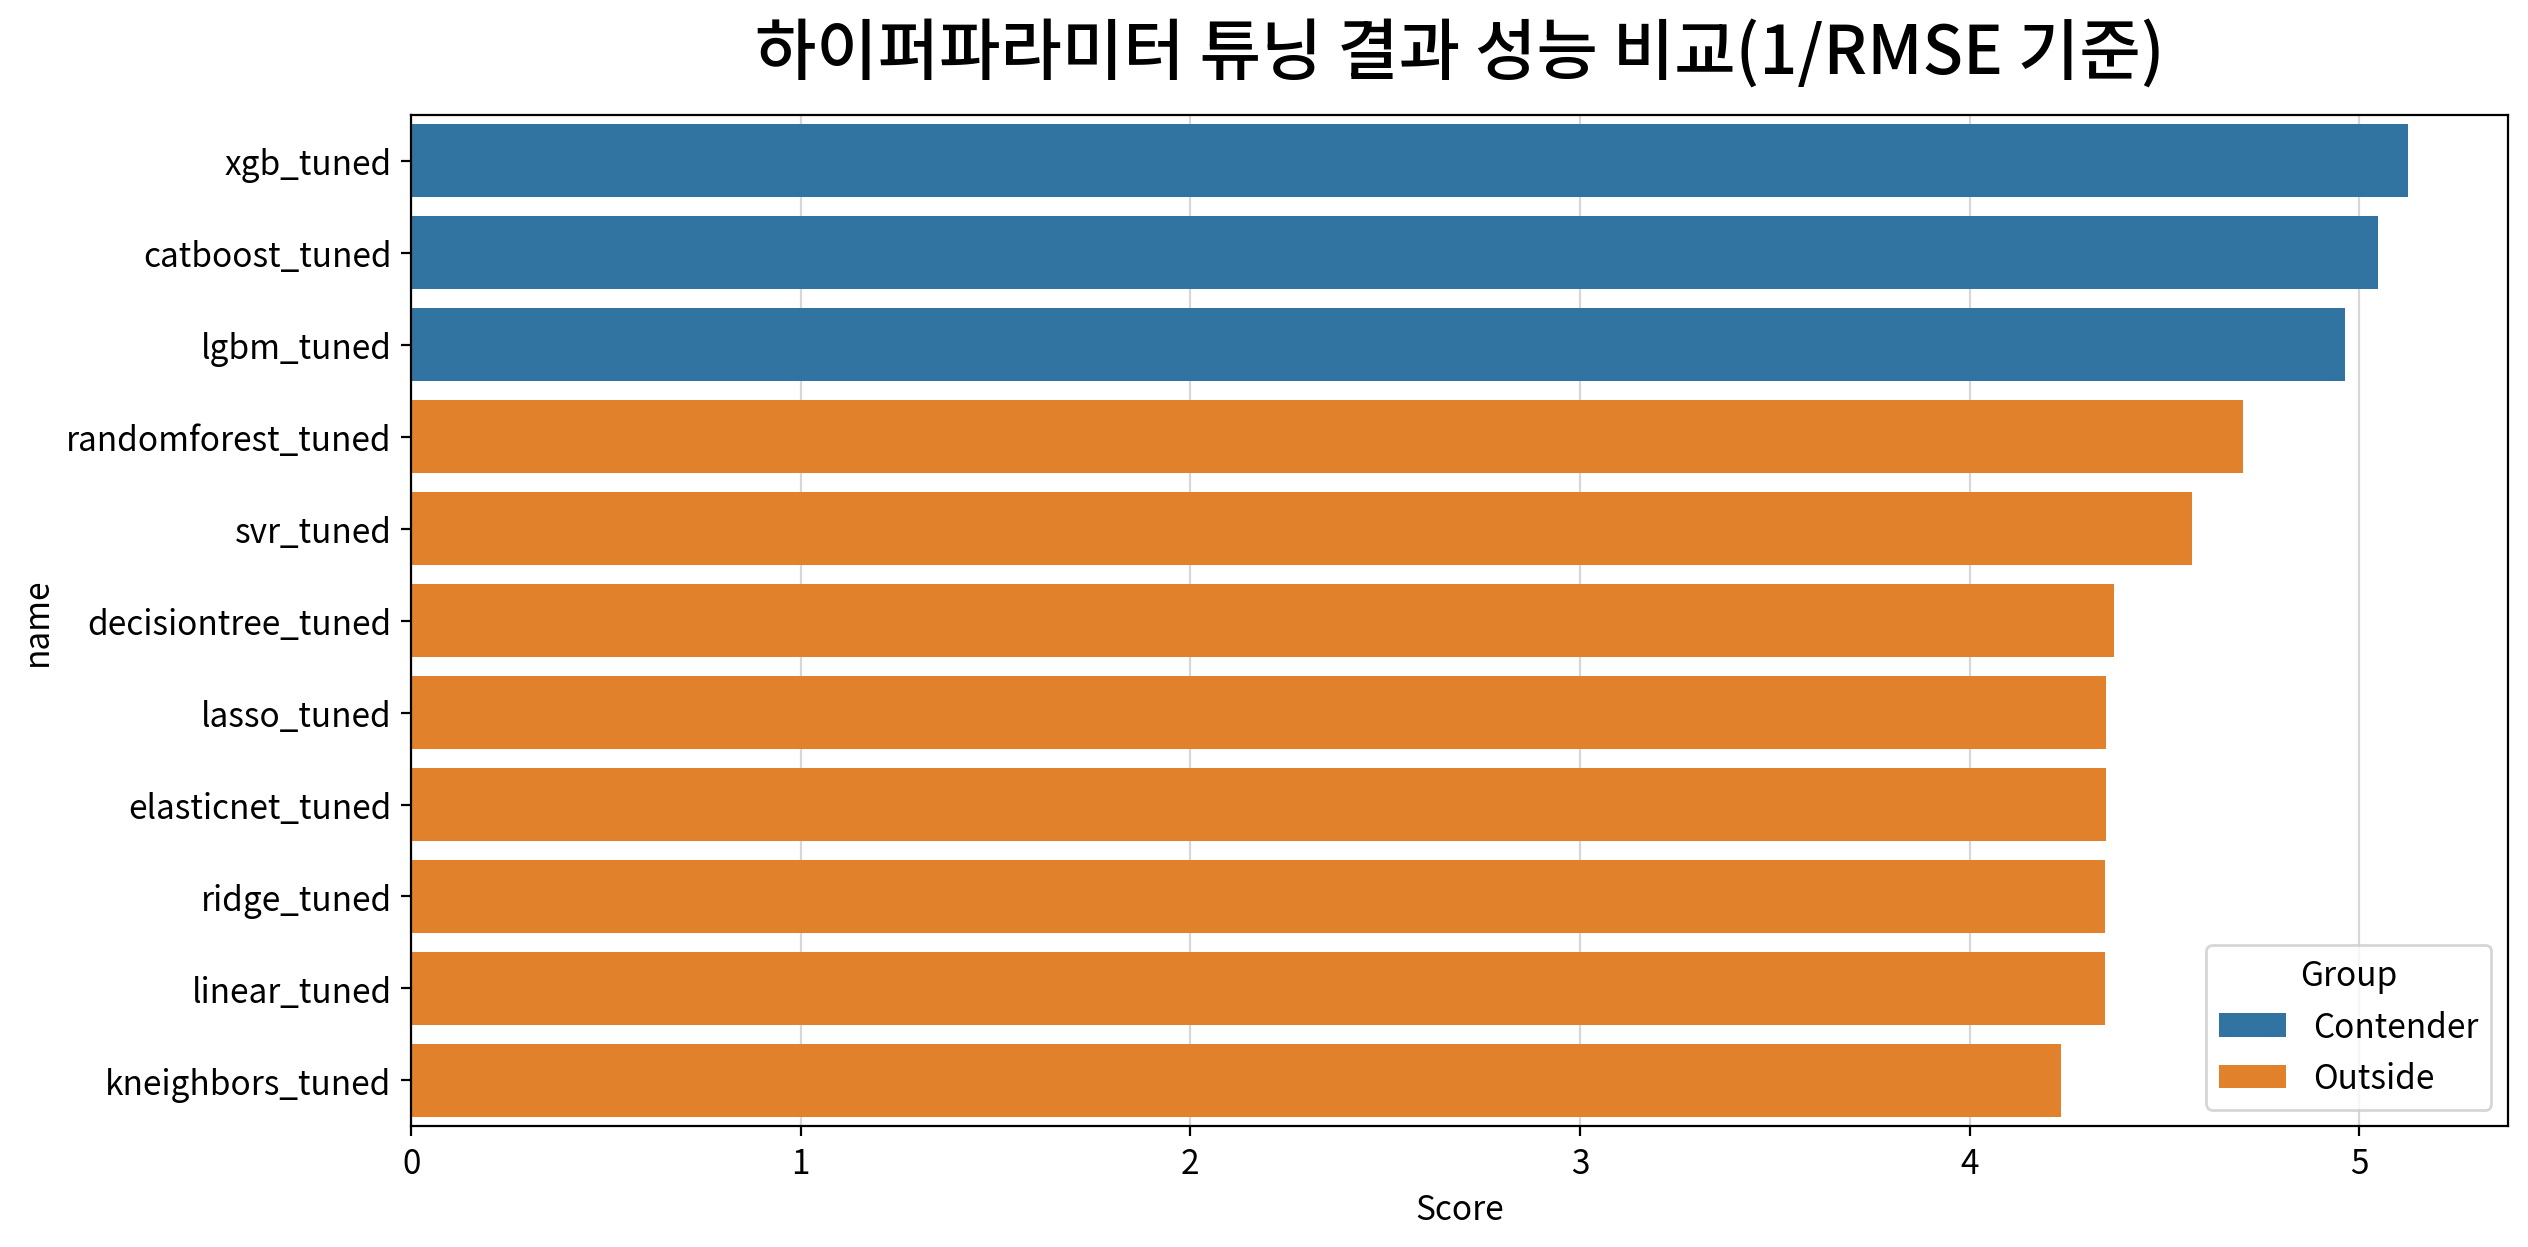


모델 11개 튜닝·저장 완료 → streeteasy\tuned


,Rank,Group,Model,R2,MAE,MSE,RMSE,RMSLE,MAPE,MPE,RMSE_Gap,Score
name,,,,,,,,,,,,
xgb_tuned,1,Contender,XGBRegressor,0.854,0.146,0.038,0.195,0.020,0.017,-0.001,0.000,5.126
catboost_tuned,2,Contender,CatBoostRegressor,0.850,0.146,0.039,0.198,0.021,0.017,-0.001,0.016,5.047
lgbm_tuned,3,Contender,LGBMRegressor,0.845,0.152,0.041,0.201,0.021,0.018,-0.001,0.033,4.964
randomforest_tuned,4,Outside,RandomForestRegressor,0.827,0.160,0.045,0.213,0.022,0.019,-0.001,0.090,4.702
svr_tuned,5,Outside,SVR,0.817,0.160,0.048,0.219,0.023,0.019,-0.001,0.122,4.570
decisiontree_tuned,6,Outside,DecisionTreeRegressor,0.800,0.173,0.052,0.229,0.024,0.021,-0.001,0.173,4.371
lasso_tuned,7,Outside,Lasso,0.798,0.173,0.053,0.230,0.024,0.021,-0.001,0.178,4.350
elasticnet_tuned,8,Outside,ElasticNet,0.798,0.173,0.053,0.230,0.024,0.021,-0.001,0.179,4.349
ridge_tuned,9,Outside,Ridge,0.798,0.173,0.053,0.230,0.024,0.021,-0.001,0.179,4.349


CPU times: total: 4min 1s
Wall time: 18min 46s


In [23]:
%%time
my_ml.reg_tunes("streeteasy", models, x_train, y_train, x_test, y_test, practice=False)

# 5부. 모델을 검증하고 해석하는 단계
### 미션 10. "점수가 배운 것인지 외운 것인지 가른다"

In [24]:
# 독립변수 분리
feature = df.drop(columns=["rent"])

# 종속변수 분리
target = df["rent"]

# 훈련, 검증 데이터 분리
# 분류 문제인 경우 파라미터 추가 --> stratify=target
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2809, 8), (703, 8), (2809,), (703,))

In [25]:
# 튜닝이 완료된 모델이 저장되어 있는 폴더 위치 지정
project_name = "streeteasy"
tuned_dir = f"{project_name}/tuned"

if not os.path.exists(tuned_dir):
    os.makedirs(tuned_dir)

In [26]:
models = {
    "catboost": my_ml.load_model(f"{tuned_dir}/catboost_tuned.pkl"),
    "xgb": my_ml.load_model(f"{tuned_dir}/xgb_tuned.pkl"),
    "lgbm": my_ml.load_model(f"{tuned_dir}/lgbm_tuned.pkl")
}

#### ▶︎ catboost

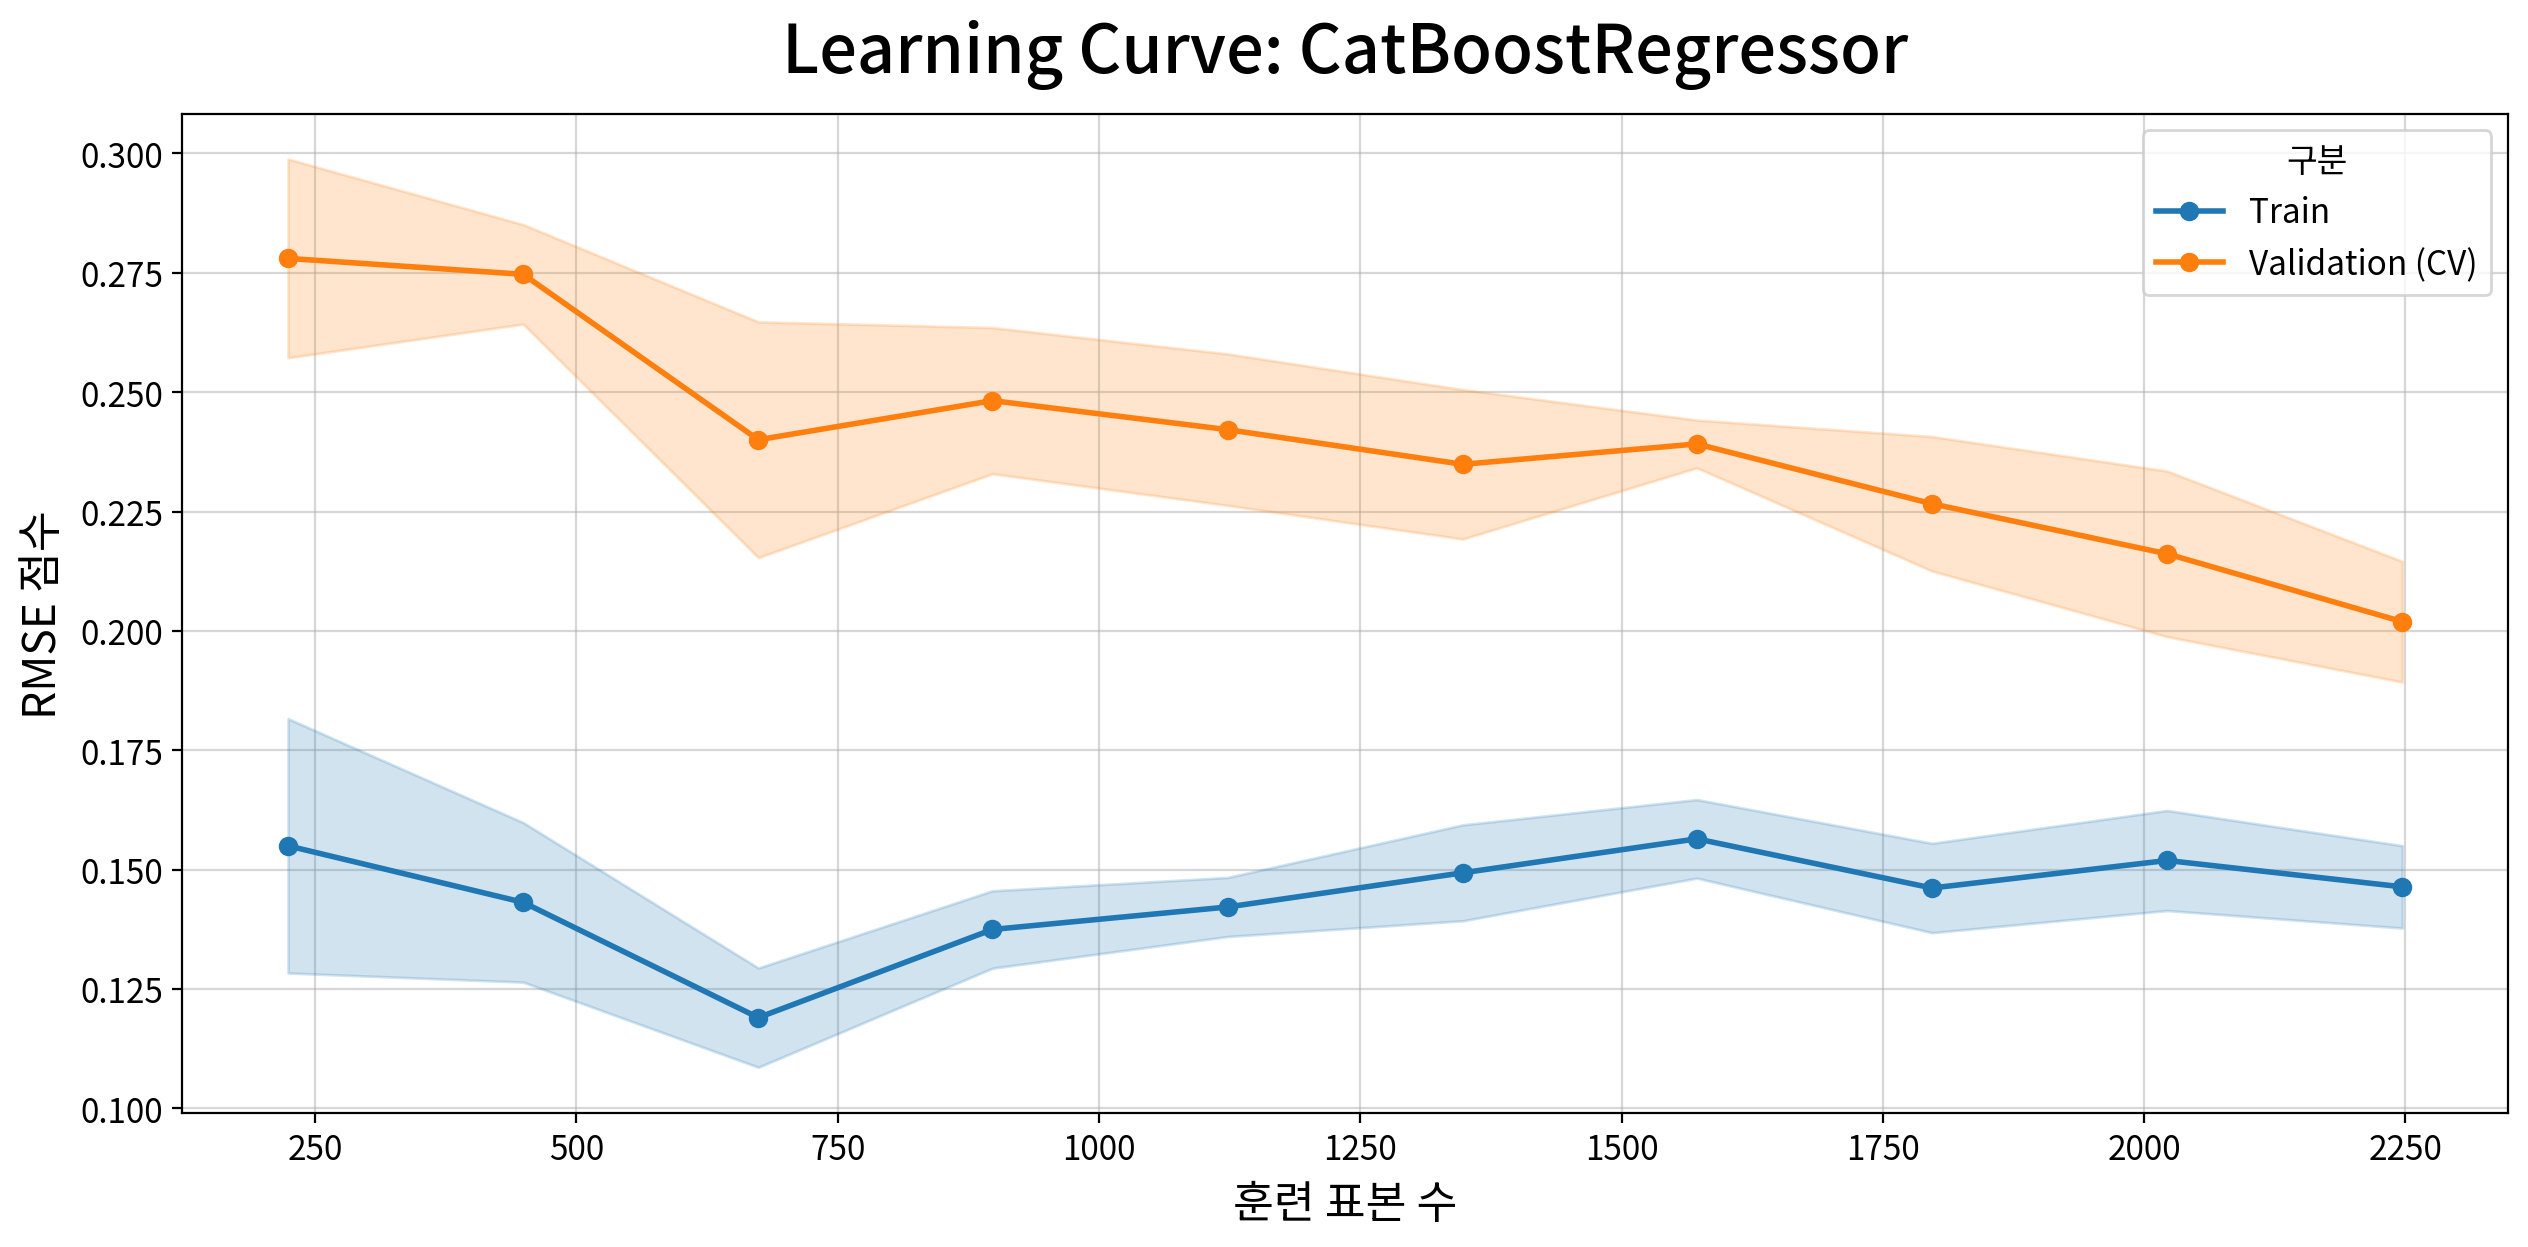

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.150,0.203,0.013,0.198,0.053,26.110,과대적합
MAE,0.112,0.151,0.007,0.146,0.039,25.720,과대적합
R2,0.911,0.836,0.027,0.850,0.075,7.510,일반화



◆ Fit Diagnosis: CatBoostRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.1498  CV=     0.2027 (±0.0128)  Test=     0.1981  Gap%=   26.11%  [과대적합] [주의]
  - MAE     Train=     0.1123  CV=     0.1511 (±0.0073)  Test=     0.1461  Gap%=   25.72%  [과대적합] [주의]
  - R2      Train=     0.9115  CV=     0.8364 (±0.0267)  Test=     0.8499  Gap%=    7.51%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9115 (과소적합 기준 < 0.05) · CV R2=0.8364



#### ▶︎ xgb

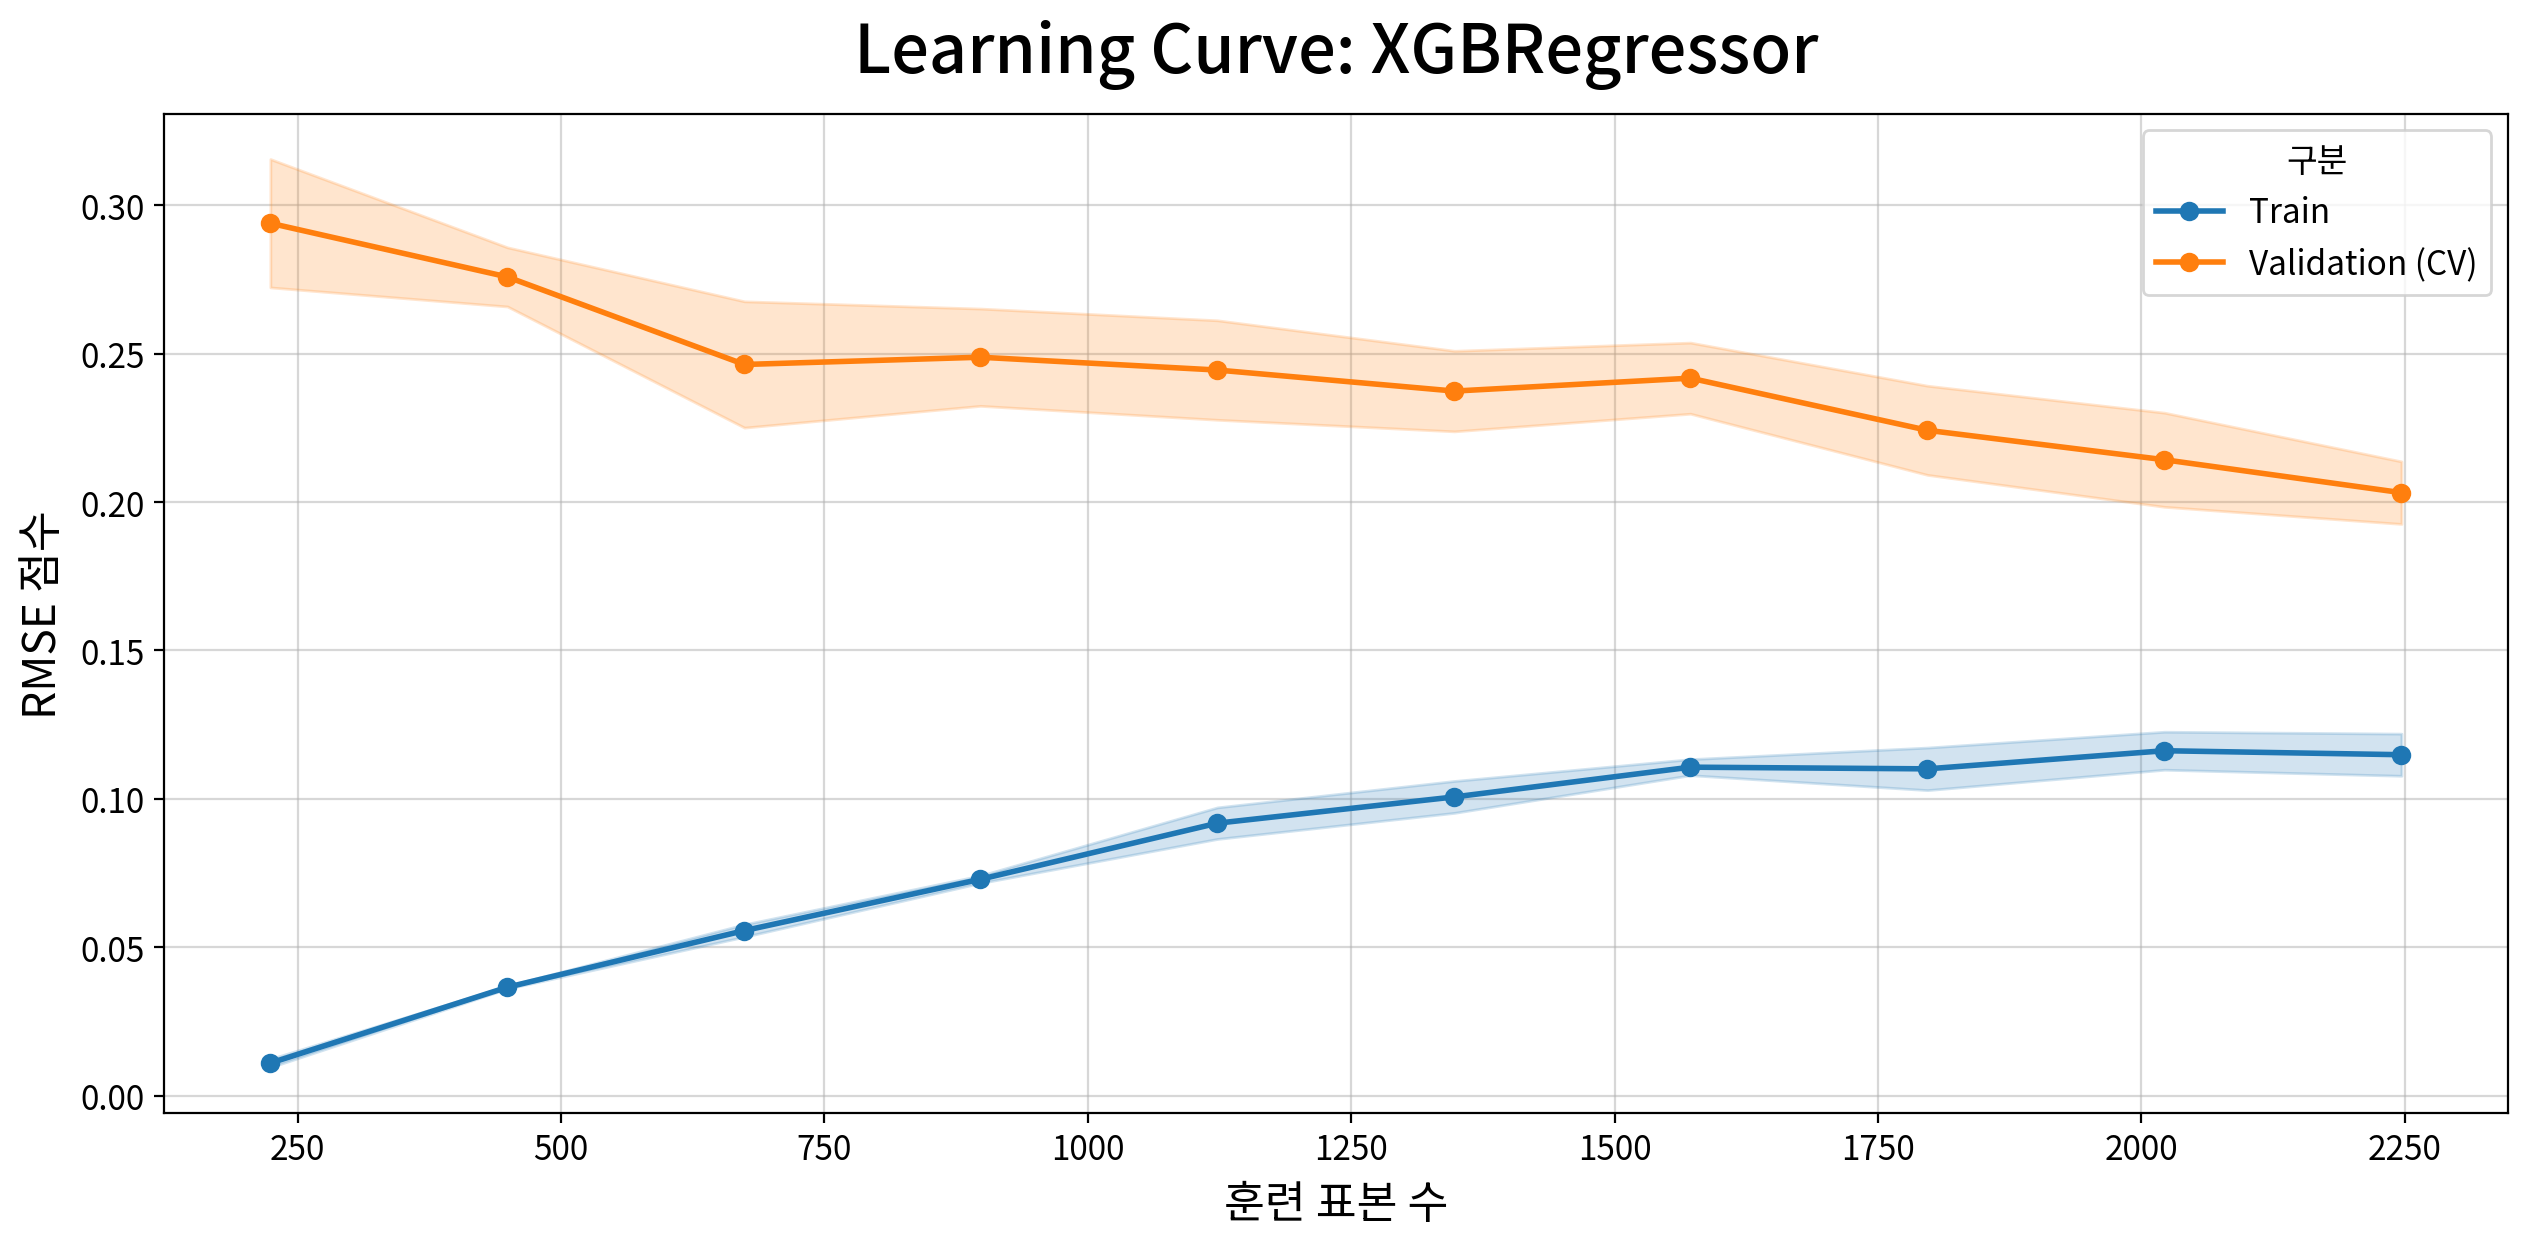

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.120,0.204,0.011,0.195,0.084,41.000,과대적합
MAE,0.089,0.151,0.007,0.146,0.062,40.960,과대적합
R2,0.943,0.835,0.023,0.854,0.108,10.800,일반화



◆ Fit Diagnosis: XGBRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.1202  CV=     0.2038 (±0.0106)  Test=     0.1951  Gap%=   41.00%  [과대적합] [주의]
  - MAE     Train=     0.0890  CV=     0.1507 (±0.0067)  Test=     0.1464  Gap%=   40.96%  [과대적합] [주의]
  - R2      Train=     0.9429  CV=     0.8349 (±0.0231)  Test=     0.8545  Gap%=   10.80%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9429 (과소적합 기준 < 0.05) · CV R2=0.8349



#### ▶︎ lgbm

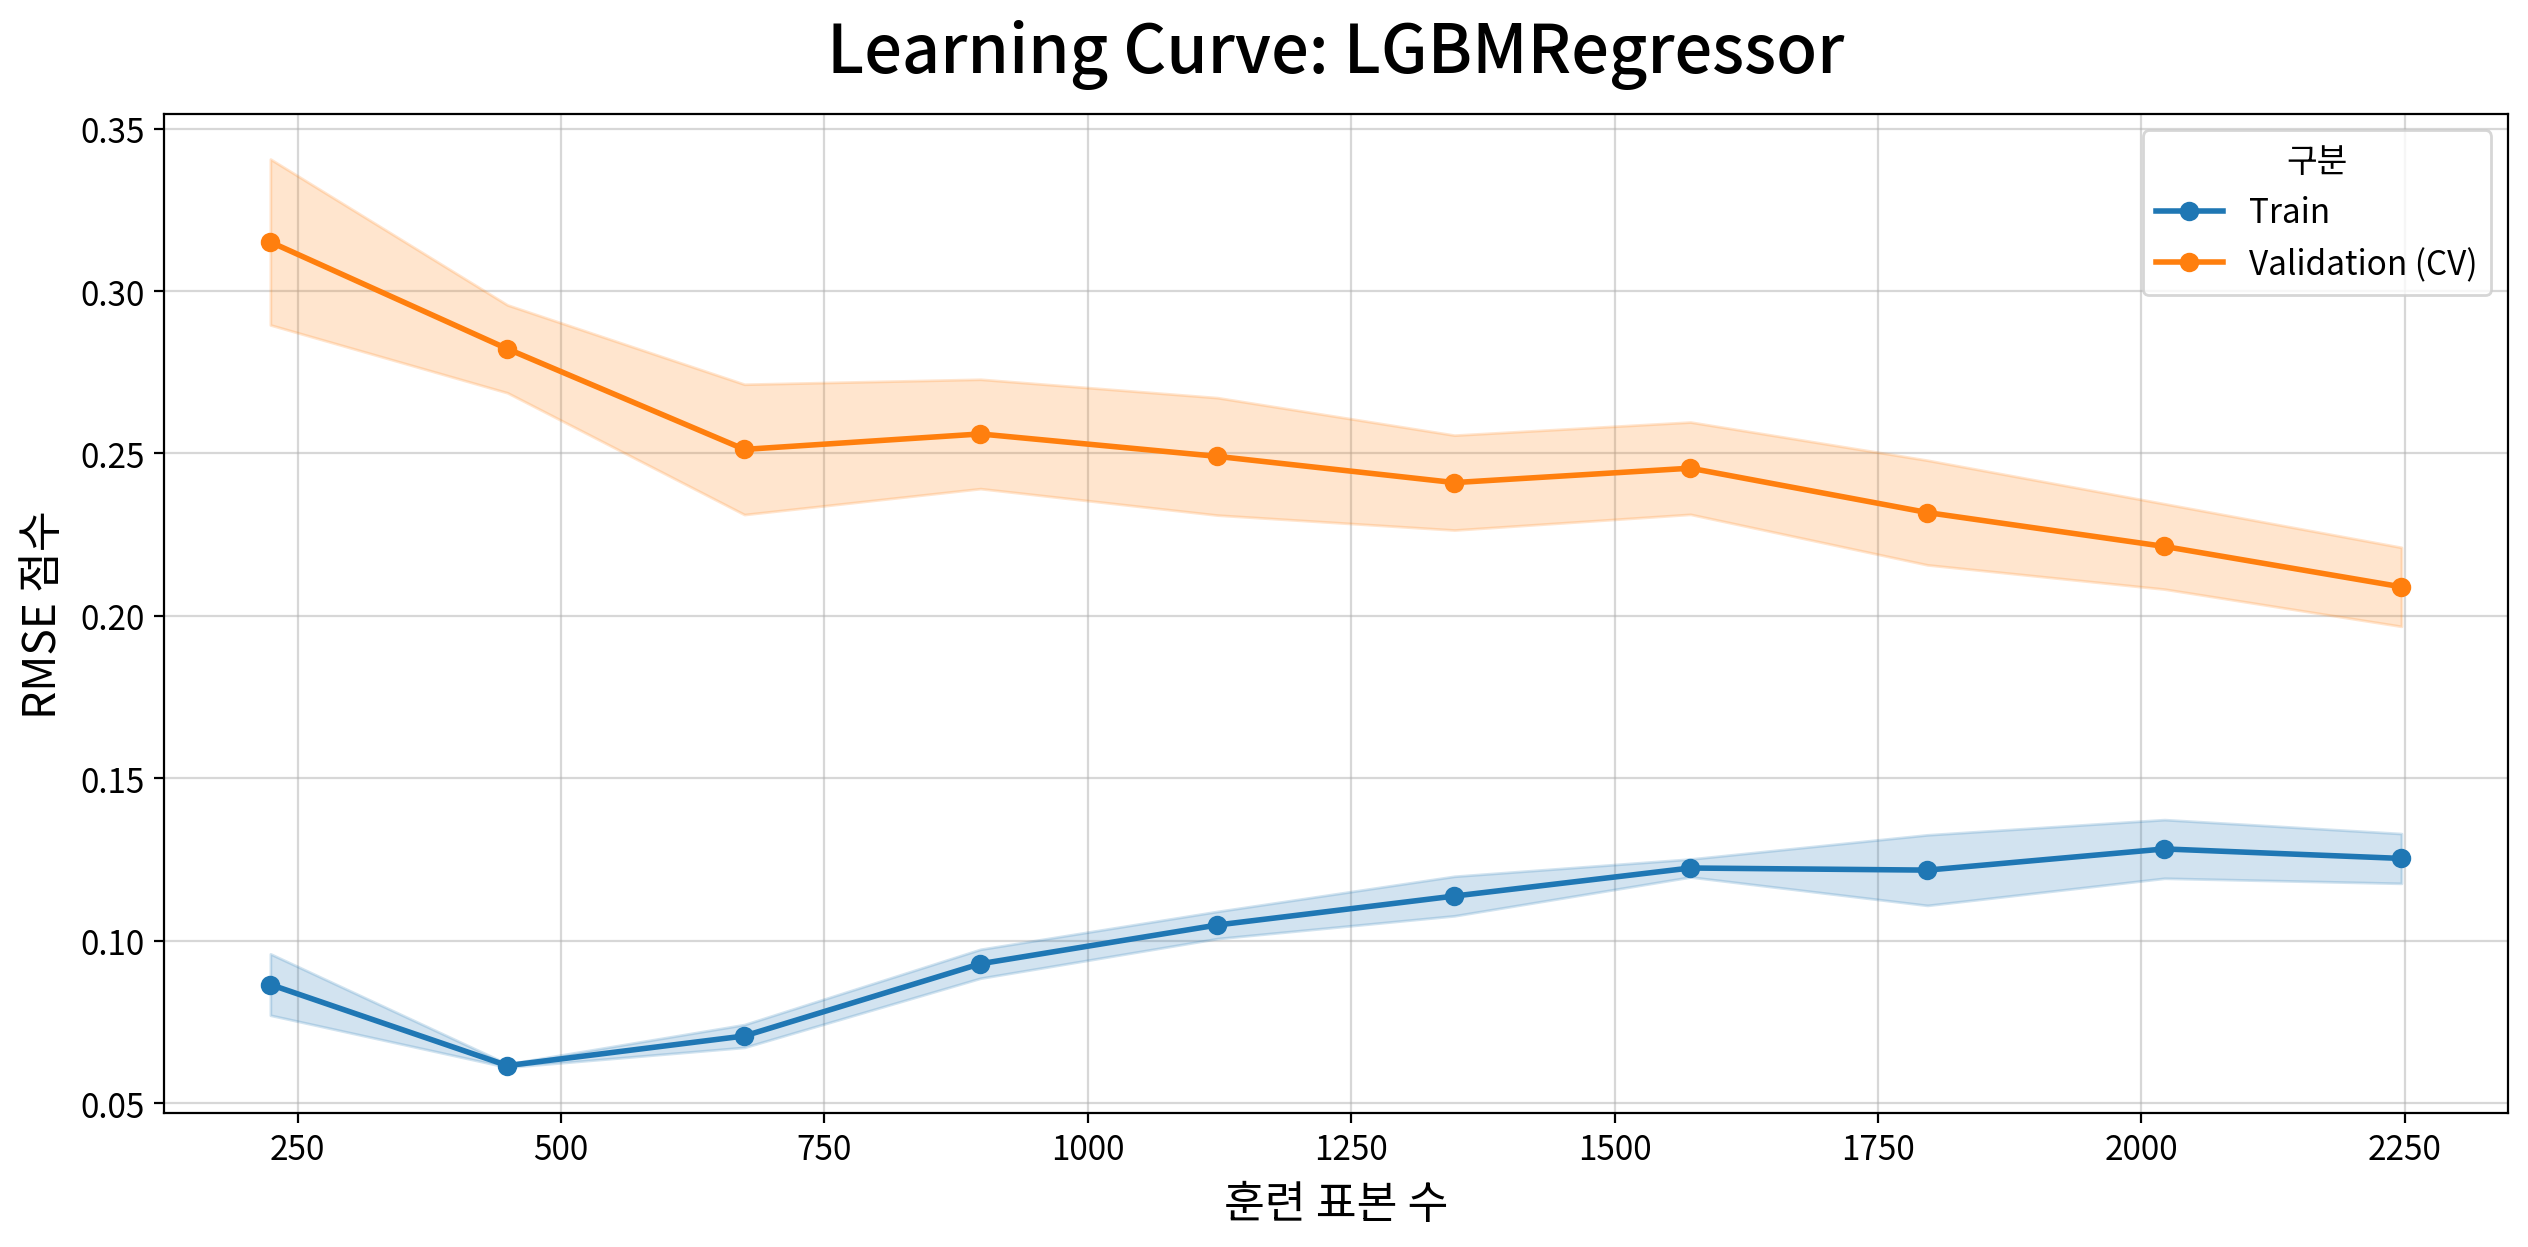

,Train,CV,CV_Std,Test,Gap,Gap%,Overfit
Metric,,,,,,,
RMSE,0.129,0.209,0.011,0.201,0.080,38.340,과대적합
MAE,0.096,0.157,0.008,0.152,0.061,39.110,과대적합
R2,0.934,0.826,0.024,0.845,0.108,10.810,일반화



◆ Fit Diagnosis: LGBMRegressor  (threshold=20%, 기준=Train↔CV 5-Fold)
   ※ threshold 는 학술 표준이 아닌 경험칙입니다. 임계값보다 학습곡선 추세를 함께 보세요.
  - RMSE    Train=     0.1289  CV=     0.2090 (±0.0109)  Test=     0.2015  Gap%=   38.34%  [과대적합] [주의]
  - MAE     Train=     0.0957  CV=     0.1571 (±0.0076)  Test=     0.1522  Gap%=   39.11%  [과대적합] [주의]
  - R2      Train=     0.9345  CV=     0.8264 (±0.0242)  Test=     0.8448  Gap%=   10.81%  [일반화] [정상]

  ▶ 진단: ⚠ 과대적합 (Overfit · 高분산) - 훈련↔CV 격차가 큼
      · train R2=0.9345 (과소적합 기준 < 0.05) · CV R2=0.8264

CPU times: total: 3.66 s
Wall time: 4min 15s


In [27]:
%%time

for model_name, model in models.items():
    display(Markdown(f"#### ▶︎ {model_name}"))
    my_diag.overfit(model, x_train, y_train, x_test, y_test)